In [1]:
#載入套件
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
#使用資料夾內鐵達尼號的資料集，練習邏輯迴歸的處理邏輯
titanic_data = pd.read_csv('data/titanic_data.csv')
titanic_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C


<Axes: >

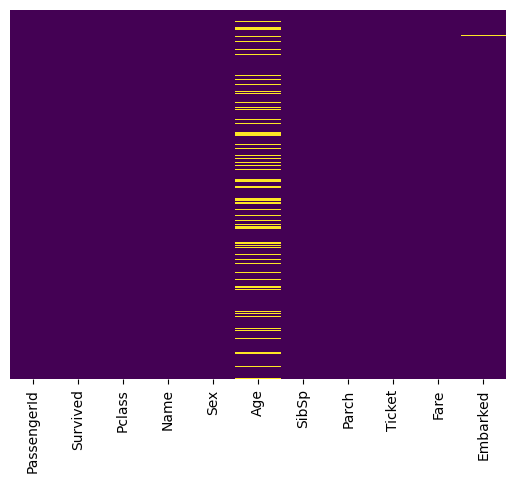

In [3]:
#探索資料
#用heatmap(.isnull()來找出缺失的資料在哪些欄位。Age似乎約有五分之一的資料缺失，可用合理資料補充。)
sns.heatmap(titanic_data.isnull(), yticklabels=False, cbar=False, cmap='viridis')

<Axes: xlabel='Survived', ylabel='count'>

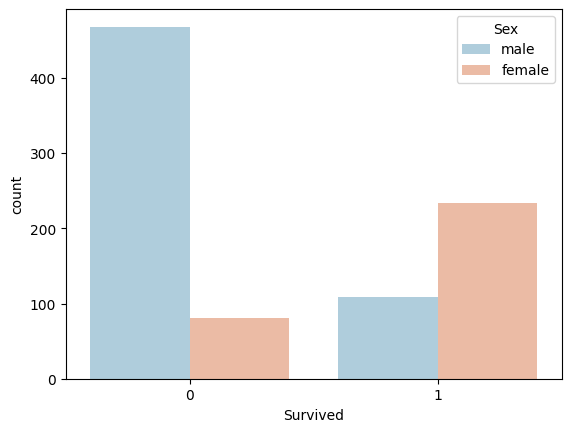

In [4]:
#用countplot來看性別是否影響最後存活。女性存活比例比男性高。
sns.countplot(x='Survived',hue='Sex', data=titanic_data, palette='RdBu_r')

<Axes: xlabel='Survived', ylabel='count'>

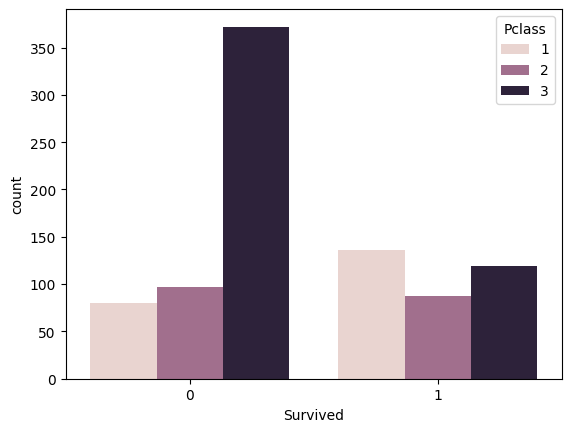

In [5]:
#艙等是否也影響存活?
sns.countplot(x='Survived',hue='Pclass',data=titanic_data)

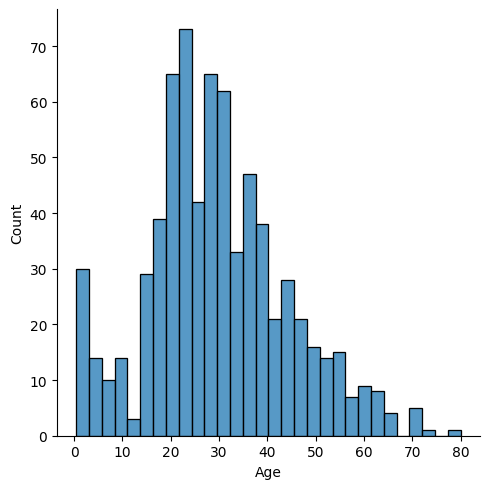

In [6]:
#用直方圖看年齡分佈。缺失資料在此不計。
sns.displot(titanic_data['Age'].dropna(), kde=False, bins=30)

<Axes: xlabel='SibSp', ylabel='count'>

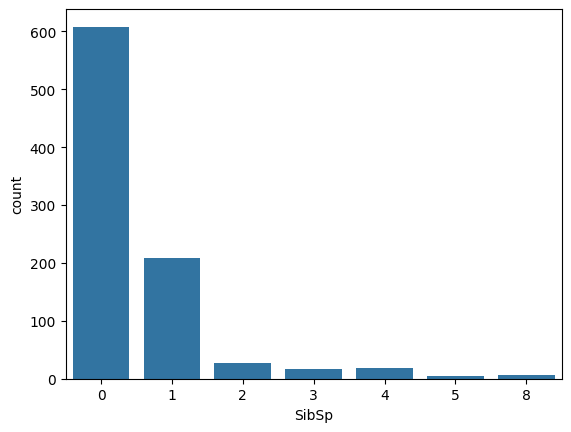

In [7]:
#SibSp代表兄弟姐妹或眷屬人數
sns.countplot(x='SibSp',data=titanic_data)

<Axes: >

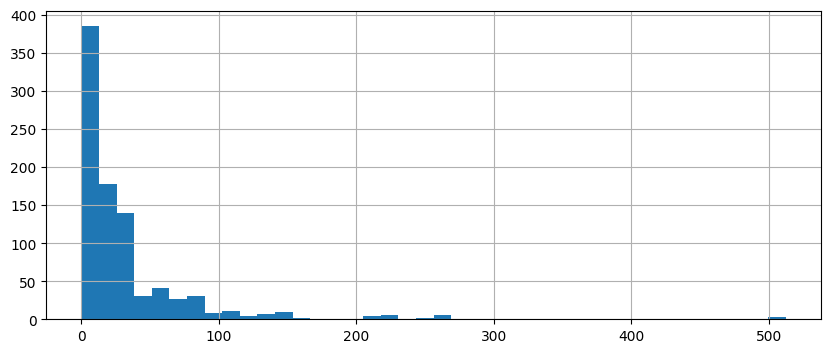

In [8]:
# 用直方圖看票價分佈
titanic_data['Fare'].hist(bins=40,figsize=(10,4))
# sns.histplot(x='Fare',data=titanic_data)

<Axes: xlabel='Pclass', ylabel='Age'>

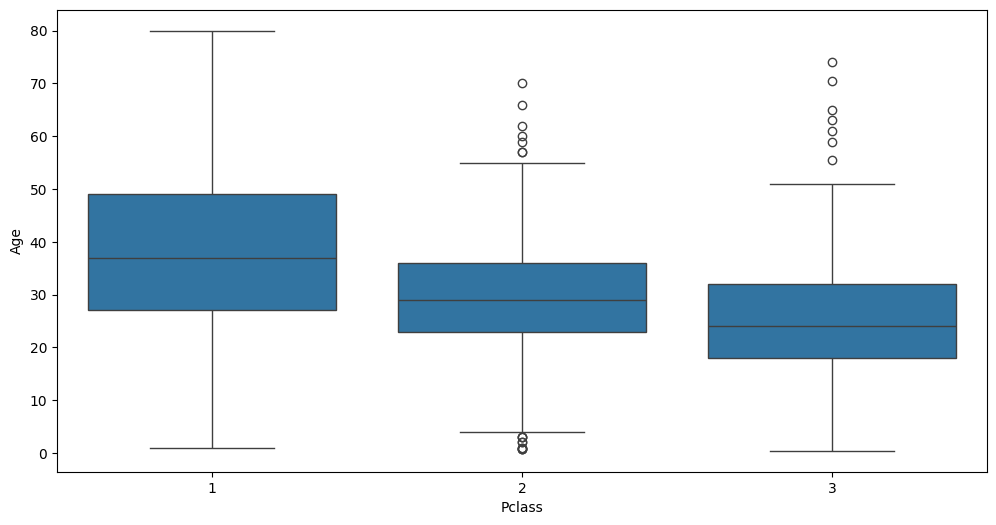

In [9]:
#資料清理
#剛有看到年齡資料約有五分之一缺失，一種做法是棄之不用，一種可以考慮把年齡平均放進去。
#使用盒鬚圖來看年齡和艙等的分佈。看起來頭等艙年齡較高，隨之降低。
plt.figure(figsize=(12,6))
sns.boxplot(x='Pclass', y='Age', data=titanic_data) # x, y順序會影響閱讀，要多加考慮

In [10]:
#把艙等平均年齡填入缺失的資料中
#艙等1平均年齡是37，艙等2平均年齡是29，艙等3平均年齡是24
# def impute_age(cols):
#     Age = cols[0]
#     Pclass = cols[1]
#     if pd.isnull(Age):
#         if Pclass == 1:
#             return 37
#         elif Pclass == 2:
#             return 29
#         else:
#             return 24
#     else:
#         return Age

# titanic_data['Age'] = titanic_data[['Age','Pclass']].apply(impute_age, axis=1)

# def impute_age(row):
#     if pd.isnull(row['Age']):
#         if row['Pclass'] == 1:
#             return 37
#         elif row['Pclass'] == 2:
#             return 29
#         else:
#             return 24
#     return row['Age']

# titanic_data['Age'] = titanic_data[['Age', 'Pclass']].apply(impute_age, axis=1)

In [11]:
mean_age_by_class = titanic_data.groupby('Pclass')['Age'].transform('mean').round(0)
titanic_data['Age'] = titanic_data['Age'].fillna(mean_age_by_class)

In [12]:
titanic_data['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    25.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

<Axes: >

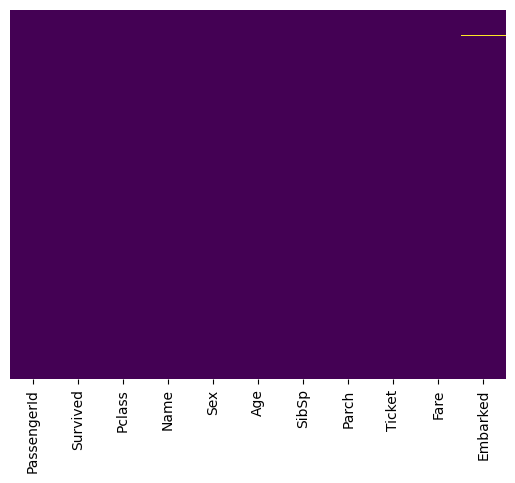

In [13]:
#用heatmap查看年齡是否還有缺失資料
sns.heatmap(titanic_data.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [14]:
titanic_data.shape

(891, 11)

In [15]:
titanic_data.dropna(inplace=True) #inplace： False: 返回新的數據集（默認） True: 在原數據集上操作
# titanic_data.drop(columns=['Cabin'], inplace=True)
# titanic_data.dropna(subset=['Embarked'], inplace=True)
# 建議更仔細確認需要 drop 的內容

In [16]:
titanic_data.shape

(889, 11)

In [17]:
#虛擬變數範例
#使用pandas(d.get_dummies)將性別從類別資料轉為數值變數。
sex = pd.get_dummies(titanic_data['Sex'],drop_first=True, prefix='Sex')
#請將drop_first=True，如果為True會刪除第一個類別值。
#本來若有k個level，drop_first=True會只剩下k-1個level，降低共線性的可能 
# 這兩個欄位是「完全線性相關」的（資訊重複）
# 這會造成多重共線性（multicollinearity）
# 線性模型（LR / Logistic）建議要 drop_first=True
sex.head()

,Sex_male
0,True
1,False
2,False
3,False
4,True


In [18]:
#使用pandas將上船的港口從類別資料改換為數值變數(drop_first=True)
embark = pd.get_dummies(titanic_data['Embarked'], drop_first=True, prefix="Embarked")
embark.head()

,Embarked_Q,Embarked_S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


In [19]:
#將性別及上船港口的數值變數和原始的data結合
titanic_data = pd.concat([titanic_data, sex, embark], axis=1)
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,True,False,True


In [20]:
#將原始的性別、登船港口、票號、姓名欄位棄用
titanic_data.drop(['Sex','Embarked','Name','Ticket'],axis=1,inplace=True)
titanic_data.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


In [21]:
#因為PassengerId在此也只是排序，因此也棄用
titanic_data.drop('PassengerId', axis=1, inplace=True)
titanic_data.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [22]:
#建立feature資料集(選取survived以外所有欄位)與target資料集(survived)
X = titanic_data.drop('Survived', axis=1)
y = titanic_data['Survived']

In [23]:
display(
    X.head(),
    y.head()
)

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [24]:
#載入訓練組及測試組分組套件
from sklearn.model_selection import train_test_split

In [25]:
#設定隨機種子(random_state)為101，測試組比例佔30%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101, stratify = y)

In [ ]:
# from sklearn.pipeline import Pipeline 後續改進

# pipeline = Pipeline([
#     ("scaler", StandardScaler()),
#     ("model", LogisticRegression(max_iter=200))
# ])

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_std = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns = X_train.columns,
    index = X_train.index
)
X_test_std = pd.DataFrame(
    scaler.transform(X_test),
    columns = X_test.columns,
    index = X_test.index
)

In [27]:
#載入邏輯回歸
from sklearn.linear_model import LogisticRegression

In [28]:
#建立訓練組邏輯迴歸模型
logmodel = LogisticRegression(max_iter = 200) # 若用預設 100，會無法收斂到最後（出現 Warning)
logmodel.fit(X_train_std, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [29]:
#使用模型進行測試集資料的預測
y_pred_test = logmodel.predict(X_test_std)
y_pred_train = logmodel.predict(X_train_std)

In [30]:
#ground truth
print(y_test.values)
print(y_train.values)

[0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0
 0 1 1 0 1 0 0 0 0 0 1 1 1 0 1 1 0 0 0 1 0 1 1 1 0 1 0 0 1 0 0 0 1 1 1 1 0
 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0
 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 1 0 1 0 1 0 1 0 1 0 1 1 0 0 1 1 0 1 0 0 0 0
 1 0 1 1 1 0 0 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0 0 0 1 0 1 1 0 0 1 0 0 1 0 1
 0 0 1 0 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0
 1 1 1 0 0 1 0 0 0 0 1 0 1 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 0 1 1 0
 0 0 1 0 1 0 1 0]
[1 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 1 1 1 0 1 0 0 1 0 0 1 0 1 1 1 0 1 0 0 0 1
 1 0 0 0 1 1 1 0 0 0 1 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 1 0 1 1 0 0 0 0 0 1 0
 1 0 0 0 1 0 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 1 1 1 0 1 0 0 0 1 1 0 0 0 0 1 1 1 0 0 1 0 1 0 0 1 0 1
 1 1 0 1 1 1 1 0 0 0 1 1 0 0 1 0 1 1 0 1 0 0 0 0 1 0 0 1 1 0 0 0 1 1 0 0 1
 0 1 0 

#### 計算accuracy及結果顯示
accuracy<br>
error_index #錯誤答案是哪幾筆資料<br>
miss classification #錯誤答案<br>
錯誤欄位的正確之原始資料表格

In [31]:
# error_index2=np.where(predictions2!=y_train.values)[0]
# print('train accuracy:',1-len(error_index2)/len(X_train))
# error_index=np.where(predictions!=y_test.values)[0]
# print('test accuracy:',1-len(error_index)/len(X_test))

In [32]:
# print('error_index:',error_index)
# print('miss classification :',predictions[error_index])#錯誤答案
# data_index=train.iloc[error_index].index#這裡變數train是所有資料
# train.iloc[data_index]#錯誤欄位的正確之原始資料

In [33]:
y_pred_train_series = pd.Series(y_pred_train, index=y_train.index, name="pred")
mask_train = y_pred_train_series != y_train
error_index_train = y_train[mask_train].index

y_pred_test_series = pd.Series(y_pred_test, index=y_test.index, name="pred")
mask_test = y_pred_test_series != y_test
error_index_test = y_test[mask_test].index

In [34]:
print('train miss classification :')
df_error_train = X_train.copy()
df_error_train["true"] = y_train
df_error_train["pred"] = y_pred_train_series
df_error_train["correct"] = df_error_train["true"] == df_error_train["pred"]

print("train accuracy:", df_error_train["correct"].mean())
print("error_index_train:", df_error_train[~df_error_train["correct"]].index)

display(df_error_train[~df_error_train["correct"]])

train miss classification :
train accuracy: 0.8118971061093248
error_index_train: Index([593, 377, 503, 692, 165, 701, 827, 118, 707,  85,
       ...
       712, 423, 647, 264, 854, 370,  41, 567, 782, 429],
      dtype='int64', length=117)


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,true,pred,correct
593,3,25.0,0,2,7.7500,False,True,False,0,1,False
377,1,27.0,0,2,211.5000,True,False,False,0,1,False
503,3,37.0,0,0,9.5875,False,False,True,0,1,False
692,3,25.0,0,0,56.4958,True,False,True,1,0,False
165,3,9.0,0,2,20.5250,True,False,True,1,0,False
...,...,...,...,...,...,...,...,...,...,...,...
370,1,25.0,1,0,55.4417,True,False,False,1,0,False
41,2,27.0,1,0,21.0000,False,False,True,0,1,False
567,3,29.0,0,4,21.0750,False,False,True,0,1,False
782,1,29.0,0,0,30.0000,True,False,True,0,1,False


In [35]:
print('test miss classification :')
df_error_test = X_test.copy()
df_error_test["true"] = y_test
df_error_test["pred"] = y_pred_test_series
df_error_test["correct"] = df_error_test["true"] == df_error_test["pred"]

print("test accuracy:", df_error_test["correct"].mean())
print("error_index_test:", df_error_test[~df_error_test["correct"]].index)

display(df_error_test[~df_error_test["correct"]])

test miss classification :
test accuracy: 0.7940074906367042
error_index_test: Index([ 49,  36, 414, 690, 484, 193, 549, 489, 831, 762, 828, 799, 147, 572,
       267, 447, 510, 207, 599, 882, 740, 660, 816,  68, 547, 340, 127, 852,
       564, 374, 664, 233, 673, 452,  83, 357, 622, 415, 102, 301, 498, 183,
       402,  25, 204, 111, 748, 297, 838, 729, 534, 553, 100, 502, 509],
      dtype='int64')


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,true,pred,correct
49,3,18.00,1,0,17.8000,False,False,True,0,1,False
36,3,25.00,0,0,7.2292,True,False,False,1,0,False
414,3,44.00,0,0,7.9250,True,False,True,1,0,False
690,1,31.00,1,0,57.0000,True,False,True,1,0,False
484,1,25.00,1,0,91.0792,True,False,False,1,0,False
193,2,3.00,1,1,26.0000,True,False,True,1,0,False
549,2,8.00,1,1,36.7500,True,False,True,1,0,False
489,3,9.00,1,1,15.9000,True,False,True,1,0,False
831,2,0.83,1,1,18.7500,True,False,True,1,0,False
762,3,20.00,0,0,7.2292,True,False,False,1,0,False


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_train, y_pred_train))
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       384
           1       0.78      0.71      0.74       238

    accuracy                           0.81       622
   macro avg       0.80      0.79      0.80       622
weighted avg       0.81      0.81      0.81       622

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       165
           1       0.76      0.68      0.72       102

    accuracy                           0.79       267
   macro avg       0.79      0.77      0.78       267
weighted avg       0.79      0.79      0.79       267



In [41]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_train, y_pred_train))
print(confusion_matrix(y_test, y_pred_test))

[[337  47]
 [ 70 168]]
[[143  22]
 [ 33  69]]


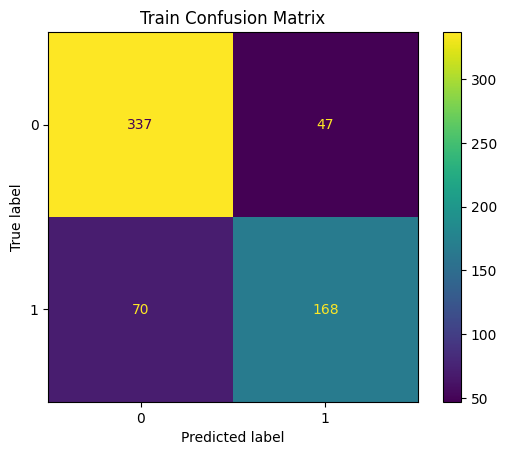

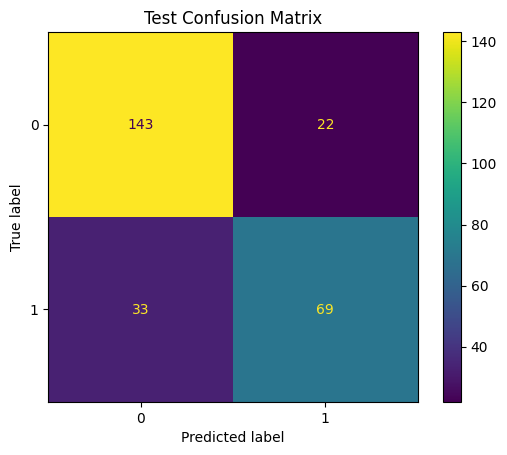

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# train
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train)
plt.title("Train Confusion Matrix")
plt.show()

# test
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
plt.title("Test Confusion Matrix")
plt.show()